# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
import numpy as np
import pandas as pd
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.utils import shuffle
from sklearn.decomposition import PCA

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
file_path = '../train_cleaned.csv'
df = pd.read_csv(file_path)

df.head()

,Customer_ID,Month,Age,Occupation,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0xd40,January,23.0,Scientist,1824.843333,3.0,4.0,3.0,4.0,Auto Loan,...,Unknown,809.98,26.822620,265.0,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,CUS_0xd40,February,23.0,Scientist,1824.843333,3.0,4.0,3.0,4.0,Auto Loan,...,Good,809.98,31.944960,268.5,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,CUS_0xd40,March,23.0,Scientist,1824.843333,3.0,4.0,3.0,4.0,Auto Loan,...,Good,809.98,28.609352,267.0,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good
3,CUS_0xd40,April,23.0,Scientist,1824.843333,3.0,4.0,3.0,4.0,Auto Loan,...,Good,809.98,31.377862,268.0,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good
4,CUS_0xd40,May,23.0,Scientist,1824.843333,3.0,4.0,3.0,4.0,Auto Loan,...,Good,809.98,24.797347,269.0,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
# Menampilkan informasi dasar mengenai dataset (jumlah baris, kolom, tipe data)
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  object 
 1   Month                     100000 non-null  object 
 2   Age                       100000 non-null  float64
 3   Occupation                100000 non-null  object 
 4   Monthly_Inhand_Salary     100000 non-null  float64
 5   Num_Bank_Accounts         100000 non-null  float64
 6   Num_Credit_Card           100000 non-null  float64
 7   Interest_Rate             100000 non-null  float64
 8   Num_of_Loan               100000 non-null  float64
 9   Type_of_Loan              100000 non-null  object 
 10  Delay_from_due_date       100000 non-null  float64
 11  Num_of_Delayed_Payment    100000 non-null  float64
 12  Changed_Credit_Limit      100000 non-null  float64
 13  Num_Credit_Inquiries      10000

In [6]:
# Menampilkan statistik deskriptif untuk kolom numerik
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
                Age  Monthly_Inhand_Salary  Num_Bank_Accounts  \
count  100000.00000          100000.000000      100000.000000   
mean       33.31111            4198.490149           5.368840   
std        10.76504            3187.491752           2.593273   
min        14.00000             303.645417           0.000000   
25%        24.00000            1626.761667           3.000000   
50%        33.00000            3095.978333           5.000000   
75%        42.00000            5961.637500           7.000000   
max        56.00000           15204.633333          11.000000   

       Num_Credit_Card  Interest_Rate    Num_of_Loan  Delay_from_due_date  \
count    100000.000000   100000.00000  100000.000000        100000.000000   
mean          5.533910       14.53208       3.532880            21.081910   
std           2.067712        8.74133       2.446356            14.840204   
min           0.000000        1.00000       0.000000             0.000000   
25% 

In [7]:
# Menampilkan jumlah nilai unik pada setiap kolom
print("\nUnique Values per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Unique Values per Column:
Customer_ID: 12500 unique values
Month: 8 unique values
Age: 80 unique values
Occupation: 15 unique values
Monthly_Inhand_Salary: 13277 unique values
Num_Bank_Accounts: 12 unique values
Num_Credit_Card: 13 unique values
Interest_Rate: 34 unique values
Num_of_Loan: 10 unique values
Type_of_Loan: 9 unique values
Delay_from_due_date: 68 unique values
Num_of_Delayed_Payment: 56 unique values
Changed_Credit_Limit: 3716 unique values
Num_Credit_Inquiries: 28 unique values
Credit_Mix: 4 unique values
Outstanding_Debt: 12203 unique values
Credit_Utilization_Ratio: 100000 unique values
Credit_History_Age: 762 unique values
Payment_of_Min_Amount: 3 unique values
Total_EMI_per_month: 11856 unique values
Amount_invested_monthly: 92646 unique values
Payment_Behaviour: 7 unique values
Monthly_Balance: 98956 unique values
Credit_Score: 3 unique values


In [8]:
# Menampilkan jumlah nilai yang hilang pada setiap kolom
print("\nMissing Values per Column:")
print(df.isnull().sum())


Missing Values per Column:
Customer_ID                 0
Month                       0
Age                         0
Occupation                  0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64


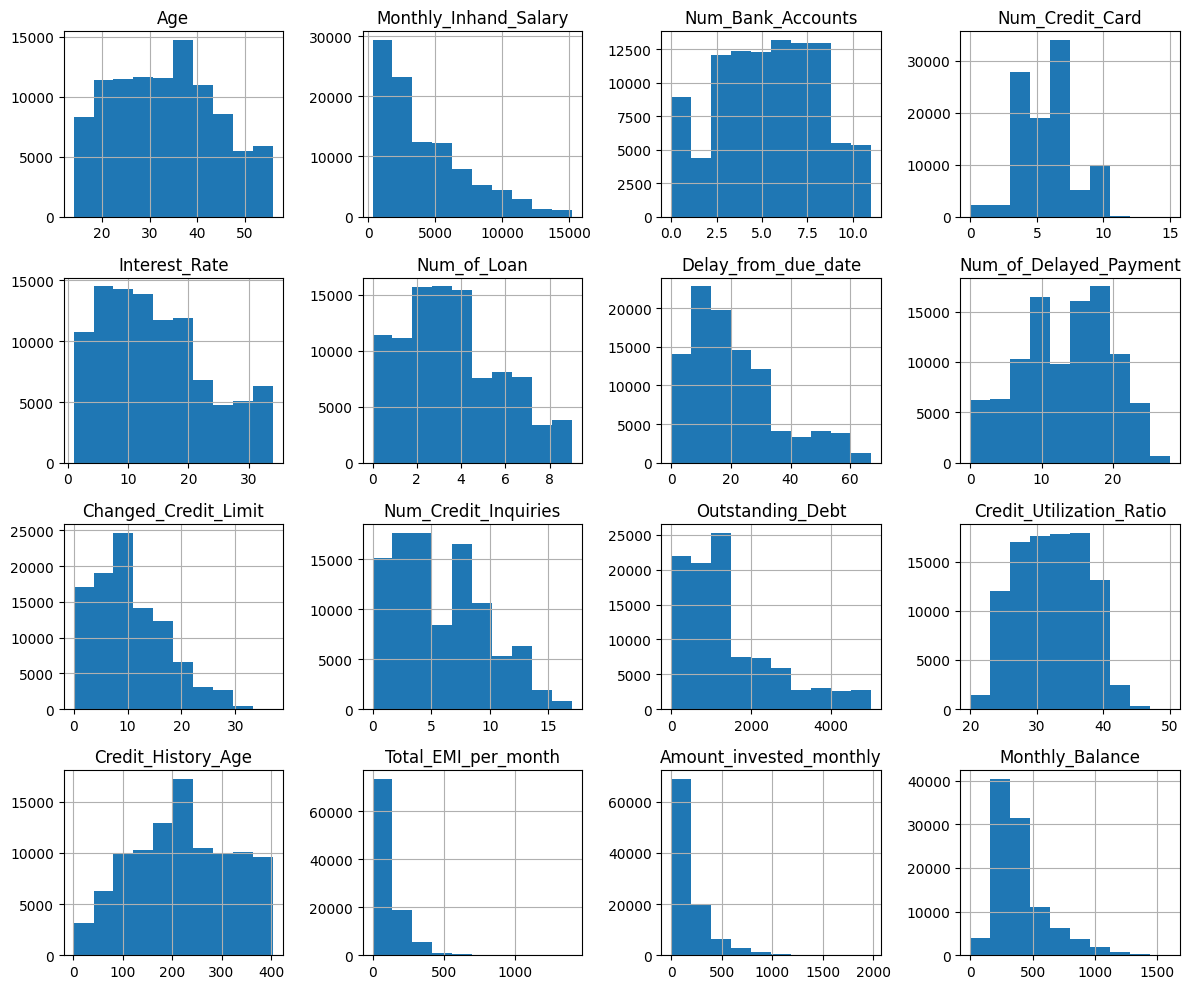

In [9]:
# Visualisasi distribusi kolom numerik (histograms)
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

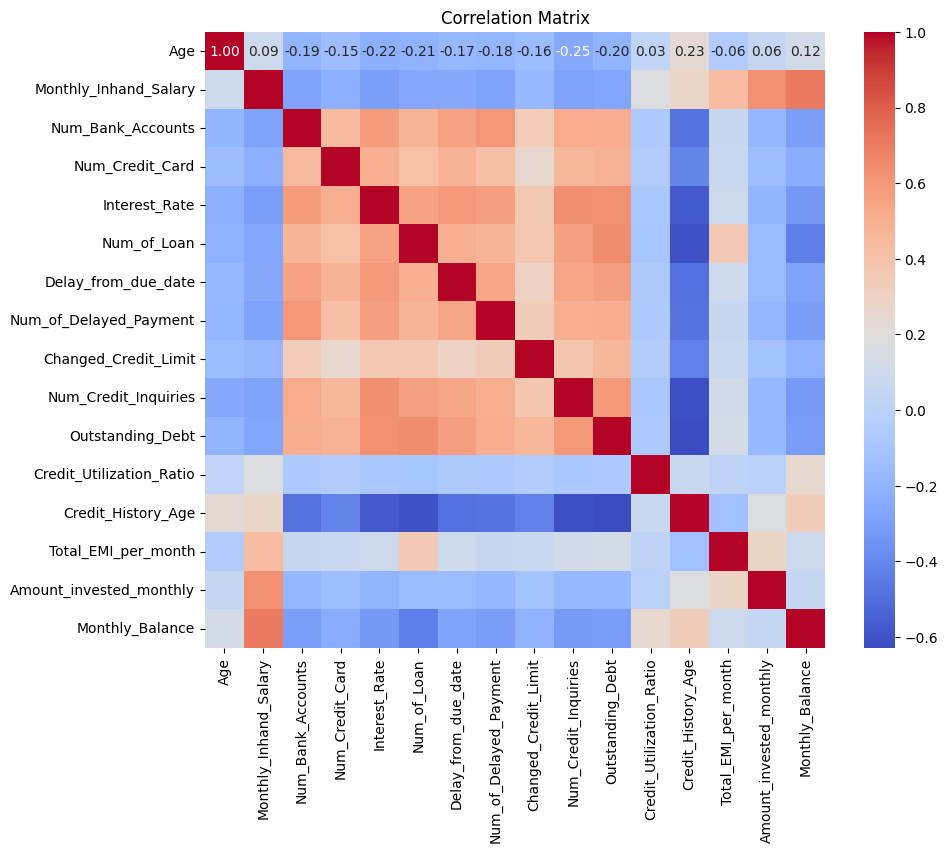

In [11]:
# Visualisasi korelasi antar kolom numerik (heatmap)
plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
# Menghapus fitur yang tidak digunakan
df = df.drop(columns=['Customer_ID', 'Month', 'Occupation', 'Type_of_Loan', 'Credit_Utilization_Ratio'], axis=1)
df.head()

,Age,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23.0,1824.843333,3.0,4.0,3.0,4.0,3.0,7.0,11.27,4.0,Unknown,809.98,265.0,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,23.0,1824.843333,3.0,4.0,3.0,4.0,0.0,6.0,11.27,4.0,Good,809.98,268.5,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,23.0,1824.843333,3.0,4.0,3.0,4.0,3.0,7.0,11.27,4.0,Good,809.98,267.0,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good
3,23.0,1824.843333,3.0,4.0,3.0,4.0,5.0,4.0,6.27,4.0,Good,809.98,268.0,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good
4,23.0,1824.843333,3.0,4.0,3.0,4.0,6.0,6.0,11.27,4.0,Good,809.98,269.0,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good


In [13]:
# Membagi data menjadi train dan testing
train_df, test_df = train_test_split(df, test_size=0.05, random_state=42, shuffle=True)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)
 
print(train_df.shape)
print(test_df.shape)

(95000, 19)
(5000, 19)


In [14]:
# Meninjau sebaran target
train_df.Credit_Score.value_counts()

Credit_Score
Standard    50525
Poor        27539
Good        16936
Name: count, dtype: int64

Karena dataset menunjukkan sebaran yang tidak seimbang (imbalance) maka perlu menyesuaikan agar seimbang.

In [15]:
df_majority_1 = train_df[(train_df.Credit_Score == "Standard")]
df_majority_2 = train_df[(train_df.Credit_Score == "Poor")]
df_minority = train_df[(train_df.Credit_Score == "Good")]

df_majority_1_undersampled = resample(df_majority_1, n_samples=16936, random_state=42)
df_majority_2_undersampled = resample(df_majority_2, n_samples=16936, random_state=42)
print(df_majority_1_undersampled.shape)
print(df_majority_2_undersampled.shape)

(16936, 19)
(16936, 19)


Pada kasus ini, saya menggunakan undersampling karena dataset sudah cukup banyak untuk kategori submission (Di atas 2500)

In [16]:
undersampled_train_df = pd.concat([df_minority, df_majority_1_undersampled]).reset_index(drop=True)
undersampled_train_df = pd.concat([undersampled_train_df, df_majority_2_undersampled]).reset_index(drop=True)
undersampled_train_df = shuffle(undersampled_train_df, random_state=42)
undersampled_train_df.reset_index(drop=True, inplace=True)
undersampled_train_df.sample(5)

,Age,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
32523,34.0,5908.350000,7.0,7.0,12.0,2.0,29.0,19.0,3.60,5.0,Good,870.47,293.0,No,119.259251,734.005674,Unknown,27.570075,Good
29034,31.0,2415.397500,4.0,5.0,8.0,2.0,14.0,13.0,9.31,1.0,Good,1348.36,288.0,No,35.818280,173.157409,Unknown,322.564062,Good
43638,23.0,7076.774926,8.0,6.0,20.0,4.0,28.0,18.0,11.79,3.0,Unknown,1323.08,357.0,No,683.411526,296.029514,Low_spent_Medium_value_payments,574.569701,Standard
49798,33.0,5941.093333,6.0,8.0,19.0,6.0,19.0,17.0,12.69,7.0,Unknown,2170.45,154.0,Yes,190.911090,215.582056,Low_spent_Small_value_payments,477.616188,Poor
28947,28.0,11257.366667,6.0,4.0,10.0,3.0,25.0,17.0,11.49,0.0,Unknown,1327.34,369.0,No,178.198183,494.210984,High_spent_Small_value_payments,842.411762,Poor


Selanjutnya, bagi dataset menjadi data train dan testing berdasarkan data yang sudah seimbang

In [17]:
X_train = undersampled_train_df.drop(columns="Credit_Score", axis=1)
y_train = undersampled_train_df["Credit_Score"]
 
X_test = test_df.drop(columns="Credit_Score", axis=1)
y_test = test_df["Credit_Score"]

Pada kasus ini, dataset numerikal memiliki rentang yang berbeda-beda. Oleh karena itu, kit adapat melakukan scaling agar memiliki rentang distribusi yang sama.

In [18]:
def scaling(features, df, df_test=None):
    if df_test is not None:
        df = df.copy()
        df_test = df_test.copy()
        for feature in features:
            scaler = MinMaxScaler()
            X = np.asanyarray(df[feature])
            X = X.reshape(-1,1)
            scaler.fit(X)
            df["{}".format(feature)] = scaler.transform(X)
            joblib.dump(scaler, "model/scaler_{}.joblib".format(feature))
            
            X_test = np.asanyarray(df_test[feature])
            X_test = X_test.reshape(-1,1)
            df_test["{}".format(feature)] = scaler.transform(X_test)
        return df, df_test
    else:
        df = df.copy()
        for feature in features:
            scaler = MinMaxScaler()
            X = np.asanyarray(df[feature])
            X = X.reshape(-1,1)
            scaler.fit(X)
            df["{}".format(feature)] = scaler.transform(X)
            joblib.dump(scaler, "model/scaler_{}.joblib".format(feature))
        return df

Agar mempermudah proses scaling, saya tentukan terlebih dahulu fitur numerikal

In [19]:
numerical_columns = [
    'Age',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance',
    'Credit_History_Age'
]

Ubah data train dan testing menggunakan fungsi scaling yang sudah dibuat. 

In [20]:
new_train_df, new_test_df = scaling(numerical_columns, X_train, X_test)

Selanjutnya, kita perlu mengelola data kategorikal karena algoritma tidak dapat menerima data selain numerikal secara cuma-cuma.

In [21]:
def encoding(features, df, df_test=None):
    if df_test is not None:
        df = df.copy()
        df_test = df_test.copy()
        for feature in features:
            encoder = LabelEncoder()
            encoder.fit(df[feature])
            df["{}".format(feature)] = encoder.transform(df[feature])
            joblib.dump(encoder, "model/encoder_{}.joblib".format(feature))
            
            df_test["{}".format(feature)] = encoder.transform(df_test[feature])
        return df, df_test
    else:
        df = df.copy()
        for feature in features:
            encoder = LabelEncoder()
            encoder.fit(df[feature])
            df["{}".format(feature)] = encoder.transform(df[feature])
            joblib.dump(encoder, "model/encoder_{}.joblib".format(feature))
        return df

Tentukan fitur kategorikal

In [22]:
categorical_columns = [
    'Credit_Mix',
    'Payment_of_Min_Amount', 
    'Payment_Behaviour'
]

Encode seluruh fitur kategorikal yang akan digunakan.

In [23]:
new_train_df, new_test_df = encoding(categorical_columns, new_train_df, new_test_df)

Encode seluruh fitur Target.

In [24]:
encoder = LabelEncoder()
encoder.fit(y_train)
new_y_train = encoder.transform(y_train)
joblib.dump(encoder, "model/encoder_target.joblib")
 
new_y_test = encoder.transform(y_test)

Karena fitur yang digunakan pada kasus ini terlalu banyak, maka saya memutuskan untuk menggunakan PCA untuk mengurangi jumlah fitur.

In [25]:
pca_numerical_columns_1 = [
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_History_Age'
]
 
pca_numerical_columns_2 = [
    'Monthly_Inhand_Salary',
    'Monthly_Balance', 
    'Amount_invested_monthly', 
    'Total_EMI_per_month'
]

Melakukan proses PCA

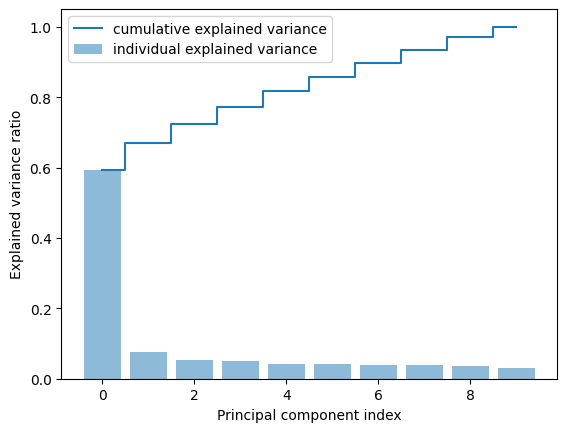

In [26]:
train_pca_df = new_train_df.copy().reset_index(drop=True)
test_pca_df = new_test_df.copy().reset_index(drop=True)
 
pca = PCA(n_components=len(pca_numerical_columns_1), random_state=123)
pca.fit(train_pca_df[pca_numerical_columns_1])
princ_comp = pca.transform(train_pca_df[pca_numerical_columns_1])
 
var_exp = pca.explained_variance_ratio_.round(3)
cum_var_exp = np.cumsum(var_exp)
 
plt.bar(range(len(pca_numerical_columns_1)), var_exp, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(len(pca_numerical_columns_1)), cum_var_exp, where='mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.show()

In [27]:
pca_1 = PCA(n_components=5, random_state=123)
pca_1.fit(train_pca_df[pca_numerical_columns_1])
joblib.dump(pca_1, "model/pca_{}.joblib".format(1))
princ_comp_1 = pca_1.transform(train_pca_df[pca_numerical_columns_1])
train_pca_df[["pc1_1", "pc1_2", "pc1_3", "pc1_4", "pc1_5"]] = pd.DataFrame(princ_comp_1, columns=["pc1_1", "pc1_2", "pc1_3", "pc1_4", "pc1_5"])
train_pca_df.drop(columns=pca_numerical_columns_1, axis=1, inplace=True)
train_pca_df.head()

,Age,Monthly_Inhand_Salary,Credit_Mix,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,pc1_1,pc1_2,pc1_3,pc1_4,pc1_5
0,0.690476,0.237662,2,2,0.113024,0.025093,0,0.266400,0.216025,0.335070,0.056151,0.047829,0.146897
1,0.190476,0.503576,1,1,0.111900,0.080054,0,0.451454,-0.319038,0.112770,0.227198,0.055694,0.117256
2,0.428571,0.090128,1,1,0.033189,0.021363,3,0.221049,-0.419239,0.069822,0.232682,-0.110793,0.251450
3,0.476190,0.126136,1,0,0.060780,0.020599,0,0.212522,-0.257237,-0.237483,0.376886,-0.068433,0.012728
4,0.452381,0.104396,1,1,0.050268,0.082627,5,0.155497,-0.502552,0.073821,0.226193,-0.284319,-0.015748


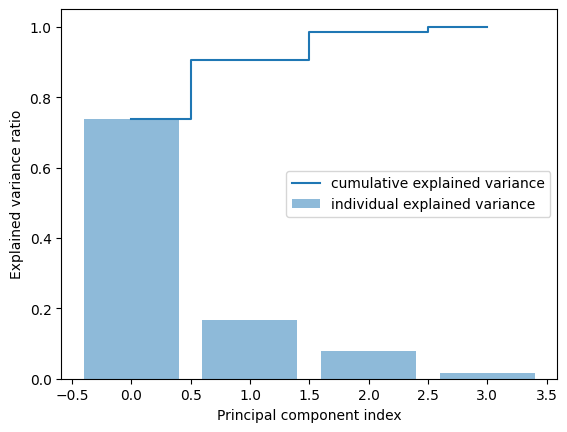

In [28]:
pca = PCA(n_components=len(pca_numerical_columns_2), random_state=123)
pca.fit(train_pca_df[pca_numerical_columns_2])
princ_comp = pca.transform(train_pca_df[pca_numerical_columns_2])
 
var_exp = pca.explained_variance_ratio_.round(3)
cum_var_exp = np.cumsum(var_exp)
 
plt.bar(range(len(pca_numerical_columns_2)), var_exp, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(len(pca_numerical_columns_2)), cum_var_exp, where='mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.show()

In [29]:
pca_2 = PCA(n_components=2, random_state=123)
pca_2.fit(train_pca_df[pca_numerical_columns_2])
joblib.dump(pca_2, "model/pca_{}.joblib".format(2))
princ_comp_2 = pca_2.transform(train_pca_df[pca_numerical_columns_2])
train_pca_df[["pc2_1", "pc2_2"]] = pd.DataFrame(princ_comp_2, columns=["pc2_1", "pc2_2"])
train_pca_df.drop(columns=pca_numerical_columns_2, axis=1, inplace=True)
train_pca_df.head()

,Age,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,pc1_1,pc1_2,pc1_3,pc1_4,pc1_5,pc2_1,pc2_2
0,0.690476,2,2,0,0.216025,0.335070,0.056151,0.047829,0.146897,-0.041306,0.042562
1,0.190476,1,1,0,-0.319038,0.112770,0.227198,0.055694,0.117256,0.278801,0.108811
2,0.428571,1,1,3,-0.419239,0.069822,0.232682,-0.110793,0.251450,-0.200276,0.056651
3,0.476190,1,0,0,-0.257237,-0.237483,0.376886,-0.068433,0.012728,-0.168980,0.037451
4,0.452381,1,1,5,-0.502552,0.073821,0.226193,-0.284319,-0.015748,-0.198335,-0.034793


In [30]:
test_princ_comp_1 = pca_1.transform(test_pca_df[pca_numerical_columns_1])
test_pca_df[["pc1_1", "pc1_2", "pc1_3", "pc1_4", "pc1_5"]] = pd.DataFrame(test_princ_comp_1, columns=["pc1_1", "pc1_2", "pc1_3", "pc1_4", "pc1_5"])
test_pca_df.drop(columns=pca_numerical_columns_1, axis=1, inplace=True)
 
test_princ_comp_1 = pca_2.transform(test_pca_df[pca_numerical_columns_2])
test_pca_df[["pc2_1", "pc2_2"]] = pd.DataFrame(test_princ_comp_1, columns=["pc2_1", "pc2_2"])
test_pca_df.drop(columns=pca_numerical_columns_2, axis=1, inplace=True)
test_pca_df.head()

,Age,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,pc1_1,pc1_2,pc1_3,pc1_4,pc1_5,pc2_1,pc2_2
0,0.380952,1,1,0,-0.587922,0.065786,-0.240490,-0.074353,0.171067,-0.029663,0.141605
1,0.095238,0,2,5,0.758476,0.284881,-0.112092,0.249101,0.199763,-0.239913,-0.016609
2,0.642857,1,1,5,-0.441061,0.204324,-0.141343,0.030958,-0.200884,0.627842,-0.212269
3,0.500000,2,2,5,0.360298,-0.117948,-0.383579,-0.236151,-0.239712,-0.196669,0.059439
4,0.309524,1,1,1,-0.504467,0.468771,-0.080085,-0.094233,-0.195185,0.255679,0.112985


In [31]:
train_pca_df

,Age,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,pc1_1,pc1_2,pc1_3,pc1_4,pc1_5,pc2_1,pc2_2
0,0.690476,2,2,0,0.216025,0.335070,0.056151,0.047829,0.146897,-0.041306,0.042562
1,0.190476,1,1,0,-0.319038,0.112770,0.227198,0.055694,0.117256,0.278801,0.108811
2,0.428571,1,1,3,-0.419239,0.069822,0.232682,-0.110793,0.251450,-0.200276,0.056651
3,0.476190,1,0,0,-0.257237,-0.237483,0.376886,-0.068433,0.012728,-0.168980,0.037451
4,0.452381,1,1,5,-0.502552,0.073821,0.226193,-0.284319,-0.015748,-0.198335,-0.034793
...,...,...,...,...,...,...,...,...,...,...,...
50803,0.809524,3,1,5,-0.635576,0.145799,-0.246169,-0.090937,0.304226,0.257879,-0.116892
50804,0.690476,2,2,1,0.280852,0.217853,0.026765,0.361747,0.315457,0.126756,-0.022089
50805,0.238095,0,2,2,0.533443,-0.146908,-0.171717,-0.112556,0.044141,-0.045215,-0.026265
50806,0.738095,1,1,3,-0.580120,-0.160754,0.230017,-0.061959,0.207276,-0.122196,-0.077088


In [32]:
combined_df = pd.concat([train_pca_df, pd.Series(new_y_train, name='Credit_Score')], axis=1)
combined_df.to_csv("train_pca.csv", index=False)

In [33]:
combined_df_train = pd.concat([test_pca_df, pd.Series(new_y_test, name='Credit_Score')], axis=1)
combined_df_train.to_csv("test_pca.csv", index=False)